Best Parameters (Thetas) - 1a: [np.float64(4786571.903669549), np.float64(717102.7070464758), np.float64(117950.99253169382), np.float64(587394.451775843), np.float64(469482.6220956605), np.float64(350825.2889768075)]
Final Training Loss: 741122329746.3052
Final Validation Loss: 870648735245.4343


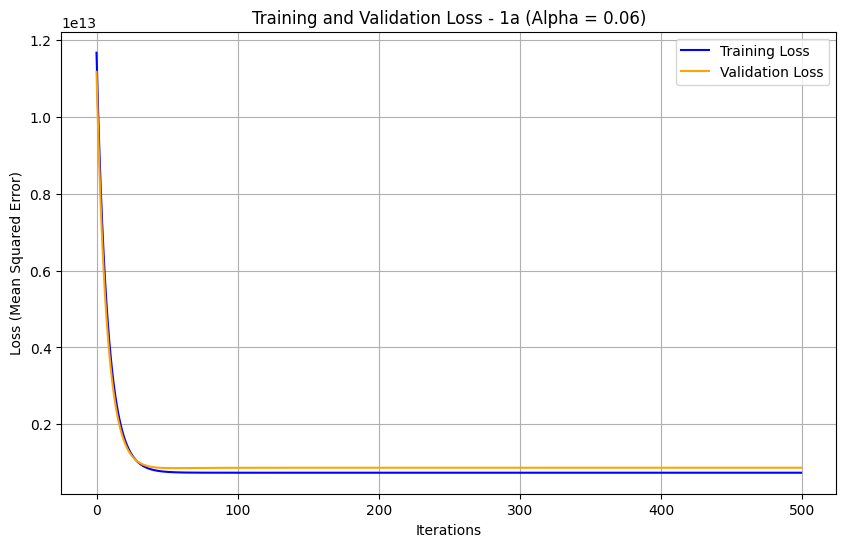

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("/content/Housing.csv")

X = data[["area", "bedrooms", "bathrooms", "stories", "parking"]].values
y = data["price"].values
m = len(y)

np.random.seed(7)
indices = np.random.permutation(m)

split_index = int(0.8 * m)

train_indices = indices[:split_index]
validation_indices = indices[split_index:]

X_train = X[train_indices]
y_train = y[train_indices]

X_val = X[validation_indices]
y_val = y[validation_indices]

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std

def GradientDescent(X_train, y_train, X_val, y_val):
  t0 = 0.0  # theta_0
  t1 = 0.0  # theta_1
  t2 = 0.0  # theta_2
  t3 = 0.0  # theta_3
  t4 = 0.0  # theta_4
  t5 = 0.0  # theta_5

  alpha = 0.06
  iterations = 500

  m_train = len(y_train)
  train_loss_history = []
  val_loss_history = []

  for i in range(iterations):
    d_t0 = 0.0
    d_t1 = 0.0
    d_t2 = 0.0
    d_t3 = 0.0
    d_t4 = 0.0
    d_t5 = 0.0

    for j in range(m_train):
      x1 = X_train[j, 0]  # area
      x2 = X_train[j, 1]  # bedrooms
      x3 = X_train[j, 2]  # bathrooms
      x4 = X_train[j, 3]  # stories
      x5 = X_train[j, 4]  # parking
      y_true = y_train[j]

      prediction = (
          t0 + (t1 * x1) + (t2 * x2) + (t3 * x3) + (t4 * x4) + (t5 * x5)
      )

      error = prediction - y_true

      d_t0 += error
      d_t1 += error * x1
      d_t2 += error * x2
      d_t3 += error * x3
      d_t4 += error * x4
      d_t5 += error * x5

    d_t0 = (1 / m_train) * d_t0
    d_t1 = (1 / m_train) * d_t1
    d_t2 = (1 / m_train) * d_t2
    d_t3 = (1 / m_train) * d_t3
    d_t4 = (1 / m_train) * d_t4
    d_t5 = (1 / m_train) * d_t5

    t0 = t0 - alpha * d_t0
    t1 = t1 - alpha * d_t1
    t2 = t2 - alpha * d_t2
    t3 = t3 - alpha * d_t3
    t4 = t4 - alpha * d_t4
    t5 = t5 - alpha * d_t5

    # Training Loss
    train_sse = 0.0
    for j in range(m_train):
      x1, x2, x3, x4, x5 = X_train[j]
      pred = t0 + (t1 * x1) + (t2 * x2) + (t3 * x3) + (t4 * x4) + (t5 * x5)
      train_sse += (pred - y_train[j]) ** 2
    train_loss = train_sse / (2 * m_train)
    train_loss_history.append(train_loss)

    # Validation Loss
    val_sse = 0.0
    for j in range(len(y_val)):
      x1, x2, x3, x4, x5 = X_val[j]
      pred = t0 + (t1 * x1) + (t2 * x2) + (t3 * x3) + (t4 * x4) + (t5 * x5)
      val_sse += (pred - y_val[j]) ** 2
    val_loss = val_sse / (2 * len(y_val))
    val_loss_history.append(val_loss)

  return (
      [t0, t1, t2, t3, t4, t5],
      train_loss_history,
      val_loss_history,
  )

best_thetas, train_losses, val_losses = GradientDescent(
    X_train, y_train, X_val, y_val
)

print("Best Parameters (Thetas) - 1a:", best_thetas)

print("Final Training Loss:", train_losses[-1])
print("Final Validation Loss:", val_losses[-1])


# Plotting losses
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.xlabel("Iterations")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("Training and Validation Loss - 1a (Alpha = 0.06)")
plt.legend()
plt.grid(True)
plt.show()

Best Parameters (Thetas) - 1b: [4786570.7398339   530188.09413277  101260.42603768  503684.30519981
  397080.66719337  157240.36666709  101945.23304287  170800.94535112
  186545.91947925  374306.52815345  285016.65411717  282526.9255569 ]
Final Training Loss: 572290915401.2432
Final Validation Loss: 571301641259.3734


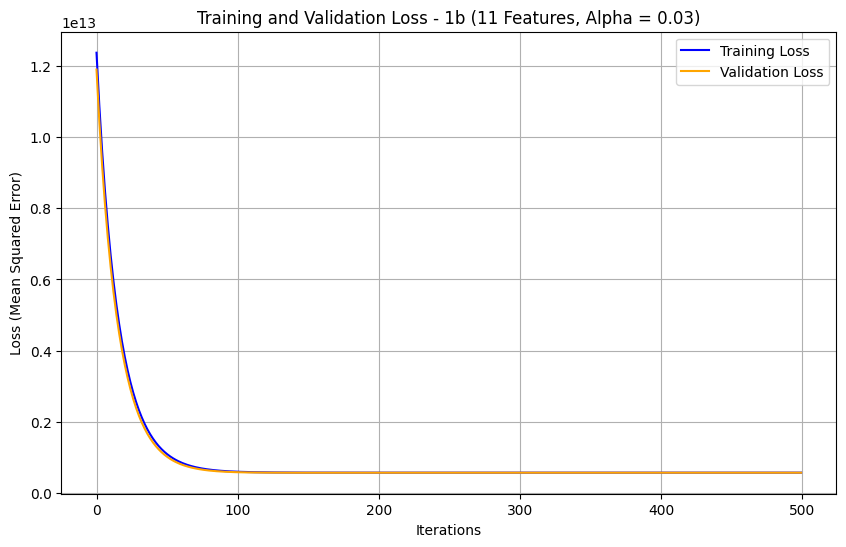

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("/content/Housing.csv")

binary_vars = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
]

for var in binary_vars:
  if var in data.columns:
    data[var] = data[var].map({"yes": 1, "no": 0})

feature_cols = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "parking",
    "prefarea",
]

X = data[feature_cols].values
y = data["price"].values
m = len(y)

np.random.seed(7)
indices = np.random.permutation(m)

split_index = int(0.8 * m)

train_indices = indices[:split_index]
validation_indices = indices[split_index:]

X_train = X[train_indices]
y_train = y[train_indices]

X_val = X[validation_indices]
y_val = y[validation_indices]

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std

def GradientDescent(X_train, y_train, X_val, y_val):

  thetas = np.zeros(12)

  alpha = 0.03
  iterations = 500

  m_train = len(y_train)
  m_val = len(y_val)
  train_loss_history = []
  val_loss_history = []

  for i in range(iterations):
    d_thetas = np.zeros(12)

    for j in range(m_train):
      x_row = X_train[j]
      y_true = y_train[j]

      prediction = thetas[0]
      for k in range(len(x_row)):
        prediction += thetas[k + 1] * x_row[k]

      error = prediction - y_true

      d_thetas[0] += error
      for k in range(len(x_row)):
        d_thetas[k + 1] += error * x_row[k]

    d_thetas = (1 / m_train) * d_thetas

    thetas = thetas - alpha * d_thetas

    train_sse = 0.0
    for j in range(m_train):
      x_row = X_train[j]
      pred = thetas[0]
      for k in range(len(x_row)):
        pred += thetas[k + 1] * x_row[k]
      train_sse += (pred - y_train[j]) ** 2
    train_loss = train_sse / (2 * m_train)
    train_loss_history.append(train_loss)

    val_sse = 0.0
    for j in range(m_val):
      x_row = X_val[j]
      pred = thetas[0]
      for k in range(len(x_row)):
        pred += thetas[k + 1] * x_row[k]
      val_sse += (pred - y_val[j]) ** 2
    val_loss = val_sse / (2 * m_val)
    val_loss_history.append(val_loss)

  return thetas, train_loss_history, val_loss_history

best_thetas, train_losses, val_losses = GradientDescent(
    X_train, y_train, X_val, y_val
)

print("Best Parameters (Thetas) - 1b:", best_thetas)

print("Final Training Loss:", train_losses[-1])
print("Final Validation Loss:", val_losses[-1])

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.xlabel("Iterations")
plt.ylabel("Loss (Mean Squared Error)")
plt.title(
    "Training and Validation Loss - 1b (11 Features, Alpha = 0.03)"
)
plt.legend()
plt.grid(True)
plt.show()

Best Parameters (Thetas) - 2a: [np.float64(2508594.062928021), np.float64(2711321.7137557124), np.float64(1428098.1600590472), np.float64(2214242.4040776757), np.float64(1791622.547120637), np.float64(1681385.4142208796)]
Final Training Loss: 813680840691.3989
Final Validation Loss: 898110374856.2671


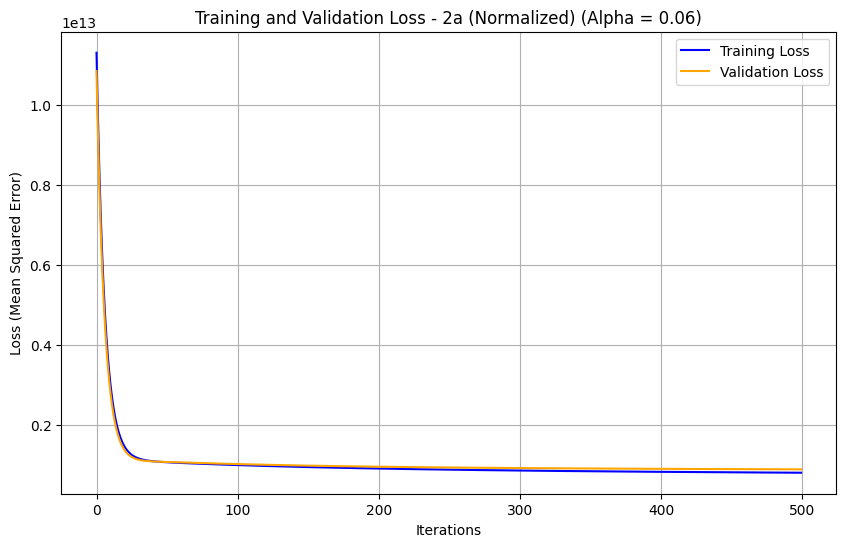

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("/content/Housing.csv")

X = data[["area", "bedrooms", "bathrooms", "stories", "parking"]].values
y = data["price"].values
m = len(y)

np.random.seed(7)
indices = np.random.permutation(m)

split_index = int(0.8 * m)

train_indices = indices[:split_index]
validation_indices = indices[split_index:]

X_train = X[train_indices]
y_train = y[train_indices]

X_val = X[validation_indices]
y_val = y[validation_indices]

X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)

X_train = (X_train - X_min) / (X_max - X_min)
X_val = (X_val - X_min) / (X_max - X_min)


def GradientDescent(X_train, y_train, X_val, y_val):
  t0 = 0.0  # theta_0
  t1 = 0.0  # theta_1
  t2 = 0.0  # theta_2
  t3 = 0.0  # theta_3
  t4 = 0.0  # theta_4
  t5 = 0.0  # theta_5

  alpha = 0.06
  iterations = 500

  m_train = len(y_train)
  train_loss_history = []
  val_loss_history = []

  for i in range(iterations):
    d_t0 = 0.0
    d_t1 = 0.0
    d_t2 = 0.0
    d_t3 = 0.0
    d_t4 = 0.0
    d_t5 = 0.0

    for j in range(m_train):
      x1 = X_train[j, 0]  # area
      x2 = X_train[j, 1]  # bedrooms
      x3 = X_train[j, 2]  # bathrooms
      x4 = X_train[j, 3]  # stories
      x5 = X_train[j, 4]  # parking
      y_true = y_train[j]

      prediction = (
          t0 + (t1 * x1) + (t2 * x2) + (t3 * x3) + (t4 * x4) + (t5 * x5)
      )

      error = prediction - y_true

      d_t0 += error
      d_t1 += error * x1
      d_t2 += error * x2
      d_t3 += error * x3
      d_t4 += error * x4
      d_t5 += error * x5

    d_t0 = (1 / m_train) * d_t0
    d_t1 = (1 / m_train) * d_t1
    d_t2 = (1 / m_train) * d_t2
    d_t3 = (1 / m_train) * d_t3
    d_t4 = (1 / m_train) * d_t4
    d_t5 = (1 / m_train) * d_t5

    t0 = t0 - alpha * d_t0
    t1 = t1 - alpha * d_t1
    t2 = t2 - alpha * d_t2
    t3 = t3 - alpha * d_t3
    t4 = t4 - alpha * d_t4
    t5 = t5 - alpha * d_t5

    # Training Loss
    train_sse = 0.0
    for j in range(m_train):
      x1, x2, x3, x4, x5 = X_train[j]
      pred = t0 + (t1 * x1) + (t2 * x2) + (t3 * x3) + (t4 * x4) + (t5 * x5)
      train_sse += (pred - y_train[j]) ** 2
    train_loss = train_sse / (2 * m_train)
    train_loss_history.append(train_loss)

    # Validation Loss
    val_sse = 0.0
    for j in range(len(y_val)):
      x1, x2, x3, x4, x5 = X_val[j]
      pred = t0 + (t1 * x1) + (t2 * x2) + (t3 * x3) + (t4 * x4) + (t5 * x5)
      val_sse += (pred - y_val[j]) ** 2
    val_loss = val_sse / (2 * len(y_val))
    val_loss_history.append(val_loss)

  return (
      [t0, t1, t2, t3, t4, t5],
      train_loss_history,
      val_loss_history,
  )

best_thetas, train_losses, val_losses = GradientDescent(
    X_train, y_train, X_val, y_val
)

print("Best Parameters (Thetas) - 2a:", best_thetas)

print("Final Training Loss:", train_losses[-1])
print("Final Validation Loss:", val_losses[-1])

# Plotting losses
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.xlabel("Iterations")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("Training and Validation Loss - 2a (Normalized) (Alpha = 0.06)")
plt.legend()
plt.grid(True)
plt.show()

Best Parameters (Thetas) - 2b: [1787360.36609168 1279100.93678555 1120039.52074525 1267577.15868654
 1323298.36676727  887965.41057278  375410.2284095   388682.0624356
  587049.83395877 1040748.25527185 1157509.96631482  750198.451089  ]
Final Training Loss: 673014073497.1997
Final Validation Loss: 656275435132.9778


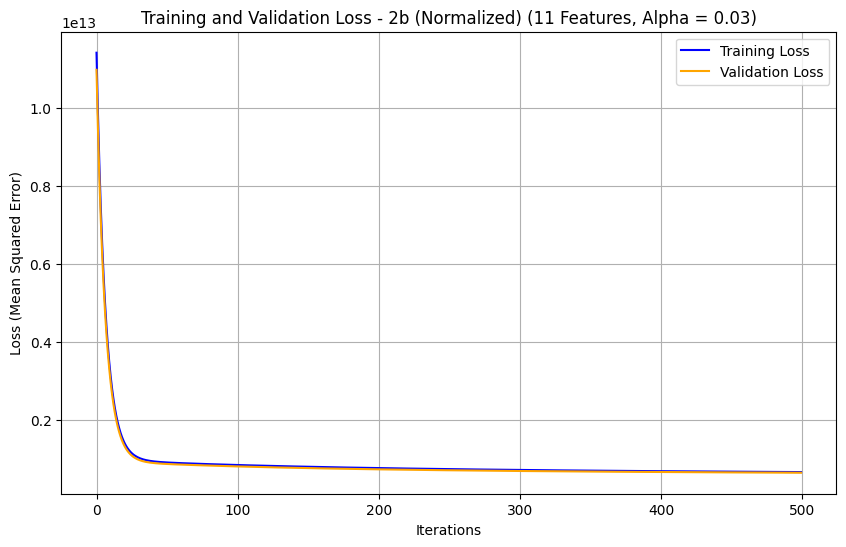

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("/content/Housing.csv")

binary_vars = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
]

for var in binary_vars:
  if var in data.columns:
    data[var] = data[var].map({"yes": 1, "no": 0})

feature_cols = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "parking",
    "prefarea",
]

X = data[feature_cols].values
y = data["price"].values
m = len(y)

np.random.seed(7)
indices = np.random.permutation(m)

split_index = int(0.8 * m)

train_indices = indices[:split_index]
validation_indices = indices[split_index:]

X_train = X[train_indices]
y_train = y[train_indices]

X_val = X[validation_indices]
y_val = y[validation_indices]

X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)

X_train = (X_train - X_min) / (X_max - X_min)
X_val = (X_val - X_min) / (X_max - X_min)

def GradientDescent(X_train, y_train, X_val, y_val):

  thetas = np.zeros(12)

  alpha = 0.03
  iterations = 500

  m_train = len(y_train)
  m_val = len(y_val)
  train_loss_history = []
  val_loss_history = []

  for i in range(iterations):
    d_thetas = np.zeros(12)

    for j in range(m_train):
      x_row = X_train[j]
      y_true = y_train[j]

      prediction = thetas[0]
      for k in range(len(x_row)):
        prediction += thetas[k + 1] * x_row[k]

      error = prediction - y_true

      d_thetas[0] += error
      for k in range(len(x_row)):
        d_thetas[k + 1] += error * x_row[k]

    d_thetas = (1 / m_train) * d_thetas

    thetas = thetas - alpha * d_thetas

    train_sse = 0.0
    for j in range(m_train):
      x_row = X_train[j]
      pred = thetas[0]
      for k in range(len(x_row)):
        pred += thetas[k + 1] * x_row[k]
      train_sse += (pred - y_train[j]) ** 2
    train_loss = train_sse / (2 * m_train)
    train_loss_history.append(train_loss)

    val_sse = 0.0
    for j in range(m_val):
      x_row = X_val[j]
      pred = thetas[0]
      for k in range(len(x_row)):
        pred += thetas[k + 1] * x_row[k]
      val_sse += (pred - y_val[j]) ** 2
    val_loss = val_sse / (2 * m_val)
    val_loss_history.append(val_loss)

  return thetas, train_loss_history, val_loss_history

best_thetas, train_losses, val_losses = GradientDescent(
    X_train, y_train, X_val, y_val
)

print("Best Parameters (Thetas) - 2b:", best_thetas)

print("Final Training Loss:", train_losses[-1])
print("Final Validation Loss:", val_losses[-1])

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.xlabel("Iterations")
plt.ylabel("Loss (Mean Squared Error)")
plt.title(
    "Training and Validation Loss - 2b (Normalized) (11 Features, Alpha = 0.03)"
)
plt.legend()
plt.grid(True)
plt.show()

Best Parameters (Thetas) - 3a: [np.float64(4786571.903669549), np.float64(715712.5334449732), np.float64(118679.08297389484), np.float64(586410.8771637195), np.float64(468552.9566134506), np.float64(350580.23845125234)]
Final Training Loss: 742515290865.4171
Final Validation Loss: 870258661294.6786


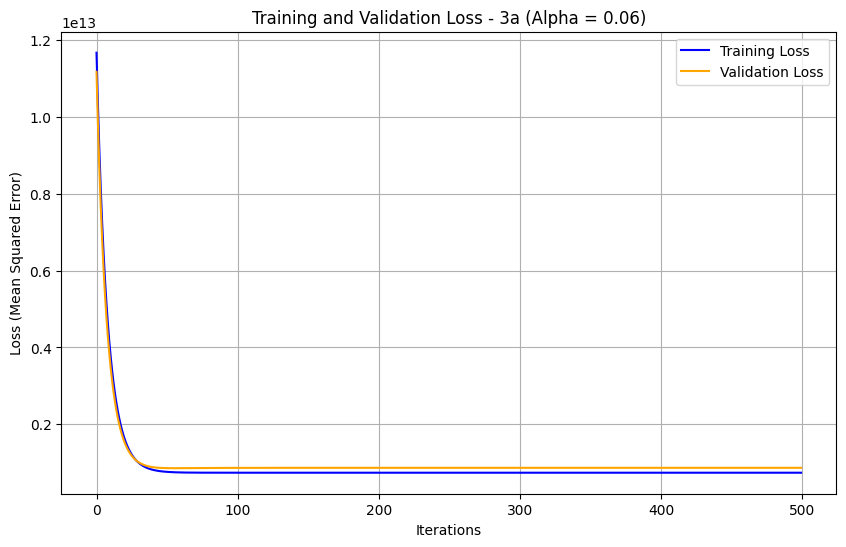

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("/content/Housing.csv")

X = data[["area", "bedrooms", "bathrooms", "stories", "parking"]].values
y = data["price"].values
m = len(y)

np.random.seed(7)
indices = np.random.permutation(m)

split_index = int(0.8 * m)

train_indices = indices[:split_index]
validation_indices = indices[split_index:]

X_train = X[train_indices]
y_train = y[train_indices]

X_val = X[validation_indices]
y_val = y[validation_indices]

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std

def GradientDescent(X_train, y_train, X_val, y_val):
  t0 = 0.0  # theta_0
  t1 = 0.0  # theta_1
  t2 = 0.0  # theta_2
  t3 = 0.0  # theta_3
  t4 = 0.0  # theta_4
  t5 = 0.0  # theta_5

  alpha = 0.06
  iterations = 500
  lambda_value = 1

  m_train = len(y_train)
  train_loss_history = []
  val_loss_history = []

  for i in range(iterations):
    d_t0 = 0.0
    d_t1 = 0.0
    d_t2 = 0.0
    d_t3 = 0.0
    d_t4 = 0.0
    d_t5 = 0.0

    for j in range(m_train):
      x1 = X_train[j, 0]  # area
      x2 = X_train[j, 1]  # bedrooms
      x3 = X_train[j, 2]  # bathrooms
      x4 = X_train[j, 3]  # stories
      x5 = X_train[j, 4]  # parking
      y_true = y_train[j]

      prediction = (
          t0 + (t1 * x1) + (t2 * x2) + (t3 * x3) + (t4 * x4) + (t5 * x5)
      )

      error = prediction - y_true

      d_t0 += error
      d_t1 += error * x1
      d_t2 += error * x2
      d_t3 += error * x3
      d_t4 += error * x4
      d_t5 += error * x5

    d_t0 = (1 / m_train) * d_t0
    d_t1 = (1 / m_train) * d_t1
    d_t2 = (1 / m_train) * d_t2
    d_t3 = (1 / m_train) * d_t3
    d_t4 = (1 / m_train) * d_t4
    d_t5 = (1 / m_train) * d_t5

    d_t1 += (lambda_value / m_train) * t1
    d_t2 += (lambda_value / m_train) * t2
    d_t3 += (lambda_value / m_train) * t3
    d_t4 += (lambda_value / m_train) * t4
    d_t5 += (lambda_value / m_train) * t5

    t0 = t0 - alpha * d_t0
    t1 = t1 - alpha * d_t1
    t2 = t2 - alpha * d_t2
    t3 = t3 - alpha * d_t3
    t4 = t4 - alpha * d_t4
    t5 = t5 - alpha * d_t5

    # Training Loss
    train_sse = 0.0
    for j in range(m_train):
      x1, x2, x3, x4, x5 = X_train[j]
      pred = t0 + (t1 * x1) + (t2 * x2) + (t3 * x3) + (t4 * x4) + (t5 * x5)
      train_sse += (pred - y_train[j]) ** 2

    penalty = lambda_value * (
        t1**2 + t2**2 + t3**2 + t4**2 + t5**2
      )

    train_loss = (train_sse + penalty) / (2 * m_train)
    train_loss_history.append(train_loss)

    # Validation Loss
    val_sse = 0.0
    for j in range(len(y_val)):
      x1, x2, x3, x4, x5 = X_val[j]
      pred = t0 + (t1 * x1) + (t2 * x2) + (t3 * x3) + (t4 * x4) + (t5 * x5)
      val_sse += (pred - y_val[j]) ** 2
    val_loss = val_sse / (2 * len(y_val))
    val_loss_history.append(val_loss)

  return (
      [t0, t1, t2, t3, t4, t5],
      train_loss_history,
      val_loss_history,
  )

best_thetas, train_losses, val_losses = GradientDescent(
    X_train, y_train, X_val, y_val
)

print("Best Parameters (Thetas) - 3a:", best_thetas)

print("Final Training Loss:", train_losses[-1])
print("Final Validation Loss:", val_losses[-1])


# Plotting losses
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.xlabel("Iterations")
plt.ylabel("Loss (Mean Squared Error)")
plt.title("Training and Validation Loss - 3a (Alpha = 0.06)")
plt.legend()
plt.grid(True)
plt.show()

Best Parameters (Thetas) - 3b: [4786570.7398339   529273.27343319  101967.41523349  502911.28834415
  396247.12782674  157440.05526181  102197.46360663  170382.60254071
  186130.32590842  373922.9734319   284844.8270586   282191.19305439]
Final Training Loss: 573554272914.3932
Final Validation Loss: 571344876150.1864


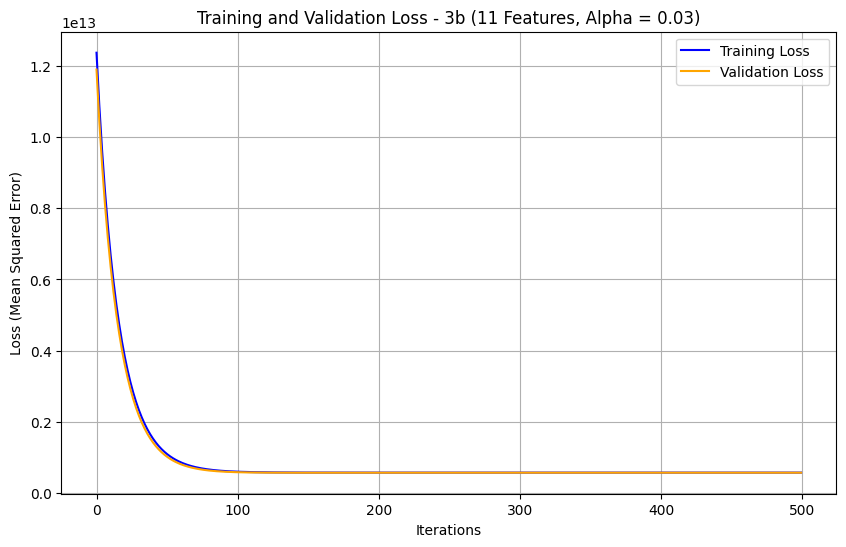

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("/content/Housing.csv")

binary_vars = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
]

for var in binary_vars:
  if var in data.columns:
    data[var] = data[var].map({"yes": 1, "no": 0})

feature_cols = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "parking",
    "prefarea",
]

X = data[feature_cols].values
y = data["price"].values
m = len(y)

np.random.seed(7)
indices = np.random.permutation(m)

split_index = int(0.8 * m)

train_indices = indices[:split_index]
validation_indices = indices[split_index:]

X_train = X[train_indices]
y_train = y[train_indices]

X_val = X[validation_indices]
y_val = y[validation_indices]

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std

def GradientDescent(X_train, y_train, X_val, y_val):

  thetas = np.zeros(12)

  alpha = 0.03
  iterations = 500
  lambda_value = 1

  m_train = len(y_train)
  m_val = len(y_val)
  train_loss_history = []
  val_loss_history = []

  for i in range(iterations):
    d_thetas = np.zeros(12)

    for j in range(m_train):
      x_row = X_train[j]
      y_true = y_train[j]

      prediction = thetas[0]
      for k in range(len(x_row)):
        prediction += thetas[k + 1] * x_row[k]

      error = prediction - y_true

      d_thetas[0] += error
      for k in range(len(x_row)):
        d_thetas[k + 1] += error * x_row[k]

    d_thetas = (1 / m_train) * d_thetas

    for k in range(1, len(thetas)):
      d_thetas[k] += (lambda_value / m_train) * thetas[k]

    thetas = thetas - alpha * d_thetas

    train_sse = 0.0
    for j in range(m_train):
      x_row = X_train[j]
      pred = thetas[0]
      for k in range(len(x_row)):
        pred += thetas[k + 1] * x_row[k]
      train_sse += (pred - y_train[j]) ** 2
    penalty = lambda_value * np.sum(thetas[1:] ** 2)
    train_loss = (train_sse + penalty) / (2 * m_train)
    train_loss_history.append(train_loss)

    val_sse = 0.0
    for j in range(m_val):
      x_row = X_val[j]
      pred = thetas[0]
      for k in range(len(x_row)):
        pred += thetas[k + 1] * x_row[k]
      val_sse += (pred - y_val[j]) ** 2
    val_loss = val_sse / (2 * m_val)
    val_loss_history.append(val_loss)

  return thetas, train_loss_history, val_loss_history

best_thetas, train_losses, val_losses = GradientDescent(
    X_train, y_train, X_val, y_val
)

print("Best Parameters (Thetas) - 3b:", best_thetas)

print("Final Training Loss:", train_losses[-1])
print("Final Validation Loss:", val_losses[-1])

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.xlabel("Iterations")
plt.ylabel("Loss (Mean Squared Error)")
plt.title(
    "Training and Validation Loss - 3b (11 Features, Alpha = 0.03)"
)
plt.legend()
plt.grid(True)
plt.show()